Parâmetros (w): [[0.06761792]
 [1.57486517]]
MSE: 0.21340090132936987


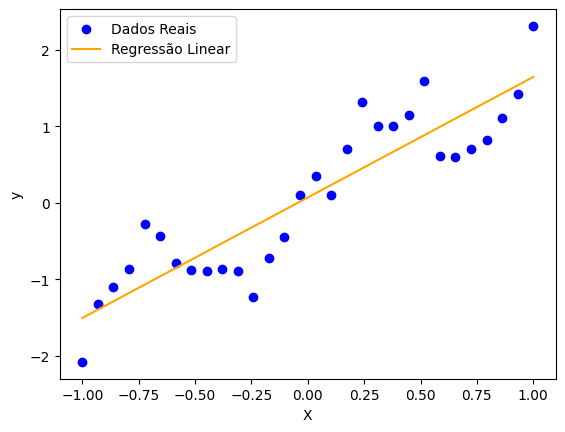

In [ ]:
# Levi Félix Barbosa - 579420

# OLS - item a)
import numpy as np
import matplotlib.pyplot as plt
import math

artificial_dataset = np.genfromtxt('./artificial1d.csv', delimiter=',')

N = artificial_dataset.shape[0]
X = np.concatenate([np.ones((N, 1)), artificial_dataset[:, [0]]], axis=1)
y = artificial_dataset[:, [1]]
w = np.linalg.inv(X.T @ X) @ X.T @ y

y_pred = X @ w

print("Parâmetros (w):", w)

mse = np.mean((y - y_pred) ** 2)
print("MSE:", mse)

plt.scatter(x=X[:, 1], y=y, label='Dados Reais', color='blue')
plt.plot(X[:, 1], y_pred, label='Regressão Linear', color='orange')

plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()


Parâmetros (w): [[0.06761792]
 [1.57486517]]
MSE: 0.21340090132936992


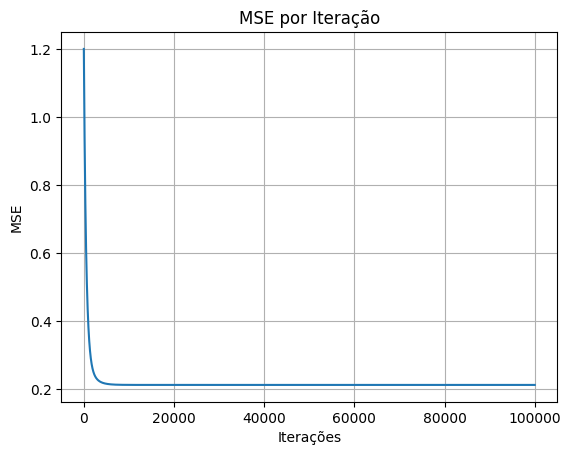

In [15]:
# GD - item b)

alfa = 0.001

w_par = np.ones((2,1))
y_pred = X @ w_par
e = y - y_pred

mse_hist = []
t=1
for t in range(0, 100000):
    y_pred = X @ w_par
    e = y - y_pred
    w_par = w_par + alfa * (X.T @ e) / N
    # para plotar:
    mse_atual = np.mean( (y-y_pred) ** 2 )
    mse_hist.append(mse_atual)

mse = np.mean((y - y_pred) ** 2)
print("Parâmetros (w):", w_par)
print("MSE:", mse)

# vamos plotar o gráfico de mse por iteração
plt.plot(range(len(mse_hist)), mse_hist)
plt.title("MSE por Iteração")
plt.xlabel("Iterações")
plt.ylabel("MSE")
plt.grid(True)
plt.show()



Parâmetros (w): [[0.06755178]
 [1.55875029]]
MSE: 0.21349343865534257


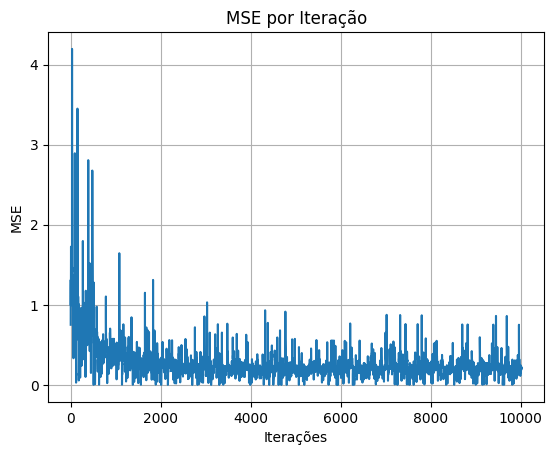

In [19]:
# SGD - item c)

alfa = 0.001

w_par = np.ones((2,1))
y_pred = X @ w_par
e = y - y_pred

mse_hist = []
t=1
while t < 10000:
    indices = np.random.permutation(N)
    x_emb = X[indices]
    y_emb = y[indices]
    erros_epoca = []
    for i in range(0, N):
        t = t+1
        y_pred_i = x_emb[i] @ w_par
        e_i = y_emb[i] - y_pred_i
        w_par = w_par + alfa * (x_emb[i].reshape(-1, 1) * e_i) 
        
        erro_quad = (e_i[0]) ** 2
        erros_epoca.append(erro_quad)  
        mse_epoca = np.mean(erros_epoca)
        mse_hist.append(mse_epoca)
    
y_pred = X @ w_par

# vamos calcular o mse

mse = np.mean( (y - y_pred) ** 2 )
print("Parâmetros (w):", w_par)
print("MSE:", mse)

# plotando

plt.plot(range(len(mse_hist)), mse_hist)
plt.title("MSE por Iteração")
plt.xlabel("Iterações")
plt.ylabel("MSE")
plt.grid(True)
plt.show()
